In [7]:
import numpy as np
import pickle
import os
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt

In [2]:
save_path = "outputs/checkpoints"
dataset_path = "outputs/datasets"
os.makedirs(dataset_path, exist_ok=True)

In [3]:

def collect_trajectory(model, env):
    """Collect a single trajectory, returning states, actions, rewards and total reward."""
    obs, _ = env.reset()
    trajectory = []
    total_reward = 0
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((obs, action, reward))
        total_reward += reward
        obs = next_obs
        done = terminated or truncated
    return trajectory, total_reward

def compute_preference_label(R1, R2):
    """Sample preference label using Bradley-Terry model with log-sum-exp trick."""
    c = max(R1, R2)
    p = np.exp(R1 - c) / (np.exp(R1 - c) + np.exp(R2 - c))
    label = np.random.choice([0, 1], p=[p, 1 - p])  # 0 = tau_1 preferred, 1 = tau_2 preferred
    return label

def generate_dataset(pi1, pi2, env, K):
    """Generate a preference dataset of K pairs."""
    dataset = []
    for _ in range(K):
        tau1, R1 = collect_trajectory(pi1, env)
        tau2, R2 = collect_trajectory(pi2, env)
        label = compute_preference_label(R1, R2)
        dataset.append({
            "tau_1": tau1,
            "tau_2": tau2,
            "R_1": R1,
            "R_2": R2,
            "label": label  # 0 = tau_1 preferred, 1 = tau_2 preferred
        })
    return dataset

In [6]:
# dataset sizes to generate
K_values = [50, 200, 500, 1000]
seeds = [0, 3, 4]
env = gym.make("CartPole-v1")

for seed in seeds:
    print(f"\n=== Generating datasets for CartPole seed {seed} ===")
    
    pi1 = PPO.load(os.path.join(save_path, f"pi1_cartpole_seed{seed}"))
    pi2 = PPO.load(os.path.join(save_path, f"pi2_cartpole_seed{seed}"))
    
    for K in K_values:
        dataset = generate_dataset(pi1, pi2, env, K)
        
        # check label distribution
        preferred_tau1 = sum(1 for d in dataset if d["label"] == 0)
        print(f"K={K}: {preferred_tau1}/{K} pairs prefer tau_1 ({100*preferred_tau1/K:.1f}%)")
        
        # save dataset
        filename = os.path.join(dataset_path, f"cartpole_seed{seed}_K{K}.pkl")
        with open(filename, "wb") as f:
            pickle.dump(dataset, f)
        print(f"Saved: {filename}")

print("\nDone! All datasets generated.")


=== Generating datasets for CartPole seed 0 ===
K=50: 50/50 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed0_K50.pkl
K=200: 200/200 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed0_K200.pkl
K=500: 499/500 pairs prefer tau_1 (99.8%)
Saved: outputs/datasets/cartpole_seed0_K500.pkl
K=1000: 1000/1000 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed0_K1000.pkl

=== Generating datasets for CartPole seed 3 ===
K=50: 50/50 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed3_K50.pkl
K=200: 200/200 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed3_K200.pkl
K=500: 500/500 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed3_K500.pkl
K=1000: 999/1000 pairs prefer tau_1 (99.9%)
Saved: outputs/datasets/cartpole_seed3_K1000.pkl

=== Generating datasets for CartPole seed 4 ===
K=50: 50/50 pairs prefer tau_1 (100.0%)
Saved: outputs/datasets/cartpole_seed4_K50.pkl
K=200: 200/200 pairs prefer tau_1 (100.0%

# CartPole datasets


=== Generating datasets for CartPole seed 0 ===


/opt/anaconda3/envs/ee-568-rl-311/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


π₁ reward: 497.9 +/- 9.2
π₂ reward: 261.2 +/- 82.2
Expected % of pairs preferring π₁: 100.0%


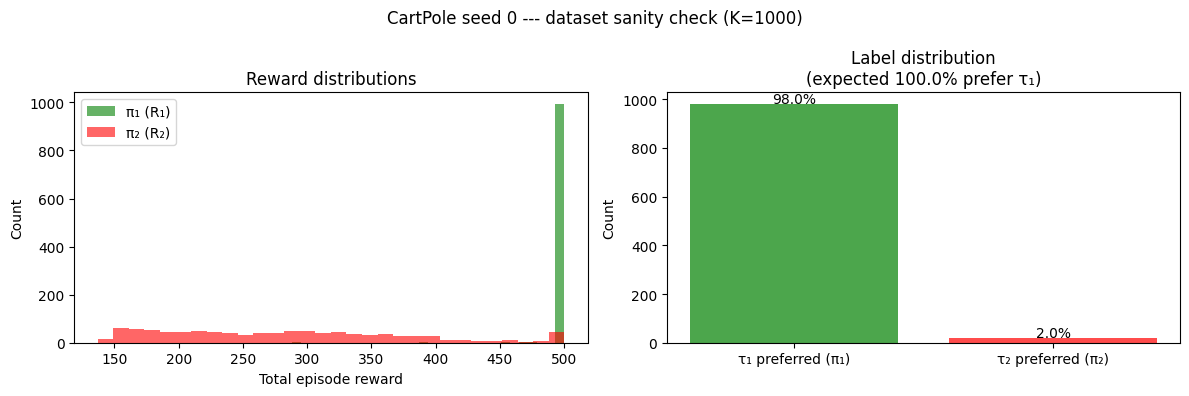

K=50: 48/50 pairs prefer τ₁ (96.0%) | avg R1=500.0, avg R2=294.8
Saved: outputs/datasets/cartpole_seed0_K50.pkl
K=200: 196/200 pairs prefer τ₁ (98.0%) | avg R1=500.0, avg R2=285.1
Saved: outputs/datasets/cartpole_seed0_K200.pkl
K=500: 489/500 pairs prefer τ₁ (97.8%) | avg R1=500.0, avg R2=284.9
Saved: outputs/datasets/cartpole_seed0_K500.pkl
K=1000: 979/1000 pairs prefer τ₁ (97.9%) | avg R1=499.5, avg R2=285.4
Saved: outputs/datasets/cartpole_seed0_K1000.pkl

=== Generating datasets for CartPole seed 3 ===
π₁ reward: 500.0 +/- 0.0
π₂ reward: 374.2 +/- 91.1
Expected % of pairs preferring π₁: 100.0%


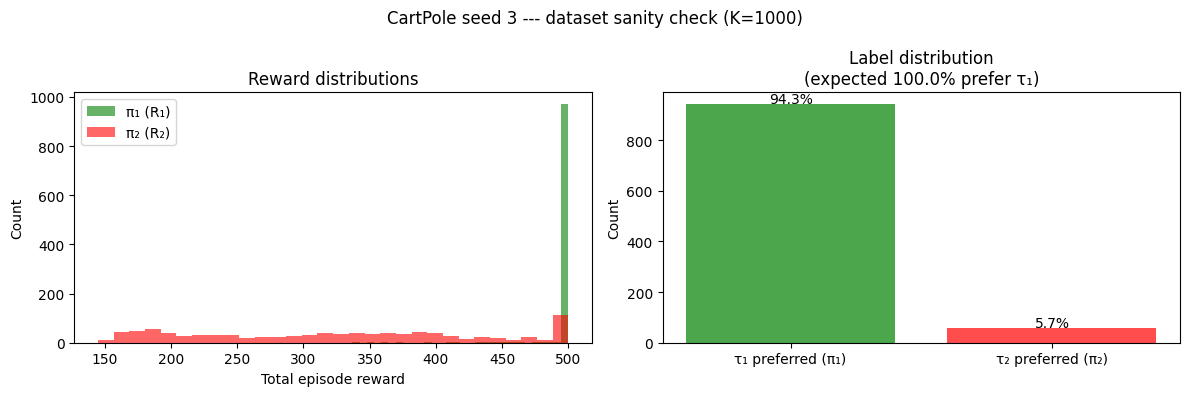

K=50: 45/50 pairs prefer τ₁ (90.0%) | avg R1=494.9, avg R2=333.6
Saved: outputs/datasets/cartpole_seed3_K50.pkl
K=200: 188/200 pairs prefer τ₁ (94.0%) | avg R1=498.3, avg R2=330.2
Saved: outputs/datasets/cartpole_seed3_K200.pkl
K=500: 461/500 pairs prefer τ₁ (92.2%) | avg R1=497.8, avg R2=325.3
Saved: outputs/datasets/cartpole_seed3_K500.pkl
K=1000: 963/1000 pairs prefer τ₁ (96.3%) | avg R1=498.3, avg R2=323.0
Saved: outputs/datasets/cartpole_seed3_K1000.pkl

=== Generating datasets for CartPole seed 4 ===
π₁ reward: 496.1 +/- 17.0
π₂ reward: 386.4 +/- 85.3
Expected % of pairs preferring π₁: 100.0%


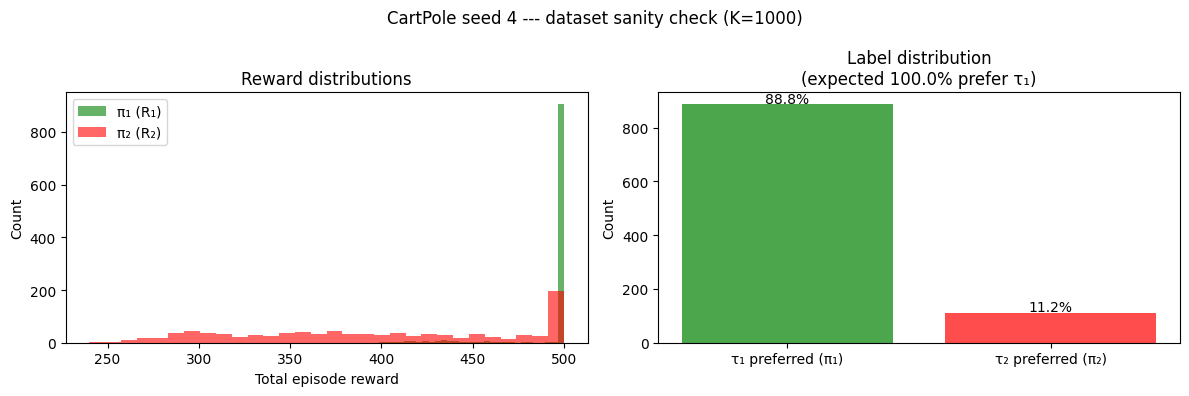

K=50: 45/50 pairs prefer τ₁ (90.0%) | avg R1=492.9, avg R2=399.7
Saved: outputs/datasets/cartpole_seed4_K50.pkl
K=200: 177/200 pairs prefer τ₁ (88.5%) | avg R1=492.4, avg R2=389.2
Saved: outputs/datasets/cartpole_seed4_K200.pkl
K=500: 440/500 pairs prefer τ₁ (88.0%) | avg R1=493.8, avg R2=398.9
Saved: outputs/datasets/cartpole_seed4_K500.pkl
K=1000: 879/1000 pairs prefer τ₁ (87.9%) | avg R1=495.3, avg R2=397.6
Saved: outputs/datasets/cartpole_seed4_K1000.pkl

Done! All datasets generated.


In [8]:

K_values = [50, 200, 500, 1000]
seeds = [0, 3, 4]
env = gym.make("CartPole-v1")

for seed in seeds:
    print(f"\n=== Generating datasets for CartPole seed {seed} ===")
    
    pi1 = PPO.load(os.path.join(save_path, f"pi1_cartpole_seed{seed}"))
    pi2 = PPO.load(os.path.join(save_path, f"pi2_cartpole_seed{seed}"))
    
    # sanity check: verify policies produce expected rewards
    mean_r1, std_r1 = evaluate_policy(pi1, env, n_eval_episodes=20, deterministic=True)
    mean_r2, std_r2 = evaluate_policy(pi2, env, n_eval_episodes=20, deterministic=True)
    print(f"π₁ reward: {mean_r1:.1f} +/- {std_r1:.1f}")
    print(f"π₂ reward: {mean_r2:.1f} +/- {std_r2:.1f}")
    
    # compute expected label rate analytically
    c = max(mean_r1, mean_r2)
    expected_p = np.exp(mean_r1 - c) / (np.exp(mean_r1 - c) + np.exp(mean_r2 - c))
    print(f"Expected % of pairs preferring π₁: {100*expected_p:.1f}%")
    
    # generate largest dataset for visualization
    dataset_1000 = generate_dataset(pi1, pi2, env, 1000)
    
    R1_list = [d["R_1"] for d in dataset_1000]
    R2_list = [d["R_2"] for d in dataset_1000]
    labels   = [d["label"] for d in dataset_1000]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"CartPole seed {seed} --- dataset sanity check (K=1000)")
    
    # plot 1: reward distributions
    axes[0].hist(R1_list, bins=30, alpha=0.6, label="π₁ (R₁)", color="green")
    axes[0].hist(R2_list, bins=30, alpha=0.6, label="π₂ (R₂)", color="red")
    axes[0].set_xlabel("Total episode reward")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Reward distributions")
    axes[0].legend()
    
    # plot 2: label distribution
    preferred_tau1 = labels.count(0)
    preferred_tau2 = labels.count(1)
    axes[1].bar(["τ₁ preferred (π₁)", "τ₂ preferred (π₂)"],
                [preferred_tau1, preferred_tau2],
                color=["green", "red"], alpha=0.7)
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Label distribution\n(expected {100*expected_p:.1f}% prefer τ₁)")
    for i, v in enumerate([preferred_tau1, preferred_tau2]):
        axes[1].text(i, v + 5, f"{100*v/1000:.1f}%", ha="center")
    
    plt.tight_layout()
    plt.show()
    
    # now generate and save all dataset sizes
    for K in K_values:
        dataset = generate_dataset(pi1, pi2, env, K)
        preferred_tau1 = sum(1 for d in dataset if d["label"] == 0)
        mean_R1 = np.mean([d["R_1"] for d in dataset])
        mean_R2 = np.mean([d["R_2"] for d in dataset])
        print(f"K={K}: {preferred_tau1}/{K} pairs prefer τ₁ ({100*preferred_tau1/K:.1f}%) | "
              f"avg R1={mean_R1:.1f}, avg R2={mean_R2:.1f}")
        
        filename = os.path.join(dataset_path, f"cartpole_seed{seed}_K{K}.pkl")
        with open(filename, "wb") as f:
            pickle.dump(dataset, f)
        print(f"Saved: {filename}")

print("\nDone! All datasets generated.")

# Pendulum datasets

In [9]:
K_values = [50, 200, 500, 1000]
seeds = [0, 1, 2]
env = gym.make("Pendulum-v1")

for seed in seeds:
    print(f"\n=== Generating datasets for Pendulum seed {seed} ===")
    pi1 = PPO.load(os.path.join(save_path, f"pi1_pendulum_seed{seed}"))
    pi2 = PPO.load(os.path.join(save_path, f"pi2_pendulum_seed{seed}"))

    # sanity check
    mean_r1, std_r1 = evaluate_policy(pi1, env, n_eval_episodes=20, deterministic=True)
    mean_r2, std_r2 = evaluate_policy(pi2, env, n_eval_episodes=20, deterministic=True)
    print(f"π₁ reward: {mean_r1:.1f} +/- {std_r1:.1f}")
    print(f"π₂ reward: {mean_r2:.1f} +/- {std_r2:.1f}")

    c = max(mean_r1, mean_r2)
    expected_p = np.exp(mean_r1 - c) / (np.exp(mean_r1 - c) + np.exp(mean_r2 - c))
    print(f"Expected % of pairs preferring π₁: {100*expected_p:.1f}%")

    for K in K_values:
        dataset = generate_dataset(pi1, pi2, env, K)
        preferred_tau1 = sum(1 for d in dataset if d["label"] == 0)
        mean_R1 = np.mean([d["R_1"] for d in dataset])
        mean_R2 = np.mean([d["R_2"] for d in dataset])
        print(f"K={K}: {preferred_tau1}/{K} pairs prefer τ₁ ({100*preferred_tau1/K:.1f}%) | "
              f"avg R1={mean_R1:.1f}, avg R2={mean_R2:.1f}")

        filename = os.path.join(dataset_path, f"pendulum_seed{seed}_K{K}.pkl")
        with open(filename, "wb") as f:
            pickle.dump(dataset, f)
        print(f"Saved: {filename}")

print("\nDone! All datasets generated.")


=== Generating datasets for Pendulum seed 0 ===
π₁ reward: -149.0 +/- 86.6
π₂ reward: -731.0 +/- 267.3
Expected % of pairs preferring π₁: 100.0%
K=50: 50/50 pairs prefer τ₁ (100.0%) | avg R1=-135.5, avg R2=-770.0
Saved: outputs/datasets/pendulum_seed0_K50.pkl
K=200: 200/200 pairs prefer τ₁ (100.0%) | avg R1=-159.0, avg R2=-815.7
Saved: outputs/datasets/pendulum_seed0_K200.pkl
K=500: 500/500 pairs prefer τ₁ (100.0%) | avg R1=-152.2, avg R2=-813.9
Saved: outputs/datasets/pendulum_seed0_K500.pkl
K=1000: 1000/1000 pairs prefer τ₁ (100.0%) | avg R1=-156.0, avg R2=-803.2
Saved: outputs/datasets/pendulum_seed0_K1000.pkl

=== Generating datasets for Pendulum seed 1 ===
π₁ reward: -127.9 +/- 98.5
π₂ reward: -892.0 +/- 151.0
Expected % of pairs preferring π₁: 100.0%
K=50: 50/50 pairs prefer τ₁ (100.0%) | avg R1=-156.6, avg R2=-889.9
Saved: outputs/datasets/pendulum_seed1_K50.pkl
K=200: 200/200 pairs prefer τ₁ (100.0%) | avg R1=-165.3, avg R2=-873.9
Saved: outputs/datasets/pendulum_seed1_K200.pk

# Try to normalize rewards using T (temp)

In [10]:
def compute_preference_label(R1, R2, temperature=1.0):
    """Sample preference label using Bradley-Terry model with temperature scaling."""
    p = np.exp(R1 / temperature) / (np.exp(R1 / temperature) + np.exp(R2 / temperature))
    label = np.random.choice([0, 1], p=[p, 1 - p])
    return label

In [11]:
def generate_dataset(pi1, pi2, env, K, temperature=1.0):
    dataset = []
    for _ in range(K):
        tau1, R1 = collect_trajectory(pi1, env)
        tau2, R2 = collect_trajectory(pi2, env)
        label = compute_preference_label(R1, R2, temperature=temperature)
        dataset.append({
            "tau_1": tau1,
            "tau_2": tau2,
            "R_1": R1,
            "R_2": R2,
            "label": label
        })
    return dataset

## Cartpole

In [13]:
K_values = [50, 200, 500, 1000]
env_cartpole = gym.make("CartPole-v1")

for seed in [0, 3, 4]:
    print(f"\n=== Generating datasets for CartPole seed {seed} ===")
    pi1 = PPO.load(os.path.join(save_path, f"pi1_cartpole_seed{seed}"))
    pi2 = PPO.load(os.path.join(save_path, f"pi2_cartpole_seed{seed}"))

    mean_r1, std_r1 = evaluate_policy(pi1, env_cartpole, n_eval_episodes=20, deterministic=True)
    mean_r2, std_r2 = evaluate_policy(pi2, env_cartpole, n_eval_episodes=20, deterministic=True)
    print(f"π₁ reward: {mean_r1:.1f} +/- {std_r1:.1f}")
    print(f"π₂ reward: {mean_r2:.1f} +/- {std_r2:.1f}")

    for K in K_values:
        dataset = generate_dataset(pi1, pi2, env_cartpole, K, temperature=100)
        preferred_tau1 = sum(1 for d in dataset if d["label"] == 0)
        mean_R1 = np.mean([d["R_1"] for d in dataset])
        mean_R2 = np.mean([d["R_2"] for d in dataset])
        print(f"K={K}: {preferred_tau1}/{K} pairs prefer τ₁ ({100*preferred_tau1/K:.1f}%) | "
              f"avg R1={mean_R1:.1f}, avg R2={mean_R2:.1f}")

        filename = os.path.join(dataset_path, f"cartpole_seed{seed}_K{K}_temperature100.pkl")
        with open(filename, "wb") as f:
            pickle.dump(dataset, f)
        print(f"Saved: {filename}")



=== Generating datasets for CartPole seed 0 ===
π₁ reward: 500.0 +/- 0.0
π₂ reward: 296.1 +/- 96.7
K=50: 41/50 pairs prefer τ₁ (82.0%) | avg R1=500.0, avg R2=291.2
Saved: outputs/datasets/cartpole_seed0_K50_temperature100.pkl
K=200: 177/200 pairs prefer τ₁ (88.5%) | avg R1=499.6, avg R2=284.2
Saved: outputs/datasets/cartpole_seed0_K200_temperature100.pkl
K=500: 433/500 pairs prefer τ₁ (86.6%) | avg R1=499.9, avg R2=277.6
Saved: outputs/datasets/cartpole_seed0_K500_temperature100.pkl
K=1000: 846/1000 pairs prefer τ₁ (84.6%) | avg R1=499.2, avg R2=286.4
Saved: outputs/datasets/cartpole_seed0_K1000_temperature100.pkl

=== Generating datasets for CartPole seed 3 ===
π₁ reward: 492.4 +/- 32.2
π₂ reward: 330.6 +/- 118.1
K=50: 46/50 pairs prefer τ₁ (92.0%) | avg R1=499.0, avg R2=310.1
Saved: outputs/datasets/cartpole_seed3_K50_temperature100.pkl
K=200: 165/200 pairs prefer τ₁ (82.5%) | avg R1=498.7, avg R2=325.7
Saved: outputs/datasets/cartpole_seed3_K200_temperature100.pkl
K=500: 395/500 pa

## Pendulum 

In [14]:
K_values = [50, 200, 500, 1000]
env_pendulum = gym.make("Pendulum-v1")

for seed in [0, 1, 2]:
    print(f"\n=== Generating datasets for Pendulum seed {seed} ===")
    pi1 = PPO.load(os.path.join(save_path, f"pi1_pendulum_seed{seed}"))
    pi2 = PPO.load(os.path.join(save_path, f"pi2_pendulum_seed{seed}"))

    mean_r1, std_r1 = evaluate_policy(pi1, env_pendulum, n_eval_episodes=20, deterministic=True)
    mean_r2, std_r2 = evaluate_policy(pi2, env_pendulum, n_eval_episodes=20, deterministic=True)
    print(f"π₁ reward: {mean_r1:.1f} +/- {std_r1:.1f}")
    print(f"π₂ reward: {mean_r2:.1f} +/- {std_r2:.1f}")

    for K in K_values:
        dataset = generate_dataset(pi1, pi2, env_pendulum, K, temperature=500)
        preferred_tau1 = sum(1 for d in dataset if d["label"] == 0)
        mean_R1 = np.mean([d["R_1"] for d in dataset])
        mean_R2 = np.mean([d["R_2"] for d in dataset])
        print(f"K={K}: {preferred_tau1}/{K} pairs prefer τ₁ ({100*preferred_tau1/K:.1f}%) | "
              f"avg R1={mean_R1:.1f}, avg R2={mean_R2:.1f}")

        filename = os.path.join(dataset_path, f"pendulum_seed{seed}_K{K}_temperature500.pkl")
        with open(filename, "wb") as f:
            pickle.dump(dataset, f)
        print(f"Saved: {filename}")

print("\nDone! All datasets generated.")


=== Generating datasets for Pendulum seed 0 ===
π₁ reward: -145.9 +/- 75.4
π₂ reward: -763.9 +/- 248.7
K=50: 40/50 pairs prefer τ₁ (80.0%) | avg R1=-128.7, avg R2=-891.6
Saved: outputs/datasets/pendulum_seed0_K50_temperature500.pkl
K=200: 164/200 pairs prefer τ₁ (82.0%) | avg R1=-147.2, avg R2=-804.0
Saved: outputs/datasets/pendulum_seed0_K200_temperature500.pkl
K=500: 379/500 pairs prefer τ₁ (75.8%) | avg R1=-152.1, avg R2=-801.5
Saved: outputs/datasets/pendulum_seed0_K500_temperature500.pkl
K=1000: 750/1000 pairs prefer τ₁ (75.0%) | avg R1=-146.1, avg R2=-797.9
Saved: outputs/datasets/pendulum_seed0_K1000_temperature500.pkl

=== Generating datasets for Pendulum seed 1 ===
π₁ reward: -150.7 +/- 88.6
π₂ reward: -908.9 +/- 154.1
K=50: 43/50 pairs prefer τ₁ (86.0%) | avg R1=-168.5, avg R2=-916.4
Saved: outputs/datasets/pendulum_seed1_K50_temperature500.pkl
K=200: 158/200 pairs prefer τ₁ (79.0%) | avg R1=-145.1, avg R2=-876.5
Saved: outputs/datasets/pendulum_seed1_K200_temperature500.pkl